# Segmentación semántica de SuperTuxKart con SAM 2

Transfer learning desde **Segment Anything Model 2** para clasificar cada píxel de un frame
del videojuego en una de 7 clases: `background`, `track`, `kart`, `pickup`, `nitro`, `bomb`,
`projectile`.

## Por qué SAM 2 no sirve tal cual

SAM 2 **no es un segmentador semántico**. Es *promptable* y *binario*: recibe una imagen más
un prompt (un punto, una caja) y devuelve la máscara del objeto señalado. No sabe qué es un
kart ni distingue siete clases.

Lo que sí tiene es un **image encoder** (Hiera + cuello FPN) entrenado sobre millones de
máscaras, cuyas features separan objetos, bordes y superficies con mucha precisión.

El transfer learning consiste en:

1. Reutilizar ese encoder, con sus pesos preentrenados, como extractor de features.
2. Descartar la *memory attention* (es para vídeo) y el *mask decoder* original (es binario).
3. Añadir **una cabeza nueva** que fusione los tres niveles del FPN y produzca 7 logits por píxel.
4. **Afinar el encoder entero** con un learning rate cien veces menor que el de la cabeza, para
   adaptarlo al aspecto de un videojuego sin destruir lo que ya sabe.

## 1. Preparación

In [1]:
import os, sys, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
from utils import (CLASS_NAMES, NUM_CLASSES, VAL_TRACKS, PALETTE, ConfusionMatrix,
                   STKSegmentationDataset, split_tracks, load_data, label_to_color,
                   overlay, format_iou_table, format_confusion, weights_from_counts)

DATA_ROOT = 'data'
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('torch', torch.__version__, '| device', device)

torch 2.14.0 | device mps


## 2. El dataset

1500 frames etiquetados de 6 circuitos, 400×400 RGB. Las máscaras son imágenes de 1 canal
donde **el valor del píxel es directamente el índice de clase** (0 a 6).

Dos reglas de carga que, si se incumplen, rompen el entrenamiento en silencio:

- La máscara **no se convierte a RGB ni se normaliza**. Un `ToTensor()` la dividiría entre
  255 y destruiría la codificación de clases.
- Al redimensionar se usa **NEAREST**, nunca interpolación. Interpolar etiquetas inventa
  clases inexistentes en los bordes entre objetos.

In [2]:
train_tracks = split_tracks(DATA_ROOT, 'train')
val_tracks   = split_tracks(DATA_ROOT, 'val')
train_ds = STKSegmentationDataset(DATA_ROOT, train_tracks, size=(448, 448))
val_ds   = STKSegmentationDataset(DATA_ROOT, val_tracks,   size=(448, 448))

print('circuitos entrenamiento :', train_tracks)
print('circuitos validacion    :', val_tracks)
print('frames  entrenamiento   :', len(train_ds))
print('frames  validacion      :', len(val_ds))

img, mask = train_ds[0]
print()
print('imagen  :', tuple(img.shape), img.dtype, '| rango [%.2f, %.2f]' % (img.min(), img.max()))
print('mascara :', tuple(mask.shape), mask.dtype, '| clases presentes', mask.unique().tolist())

circuitos entrenamiento : ['abyss', 'gran_paradiso_island', 'hacienda', 'olivermath']
circuitos validacion    : ['lighthouse', 'volcano_island']
frames  entrenamiento   : 1000
frames  validacion      : 500

imagen  : (3, 448, 448) torch.float32 | rango [0.01, 1.00]
mascara : (448, 448) torch.int64 | clases presentes [0, 1, 2, 3]


### El split es por circuito, no por frame

Los frames de un mismo circuito son casi idénticos entre sí — el kart avanza unos centímetros
por frame. Con un split aleatorio, el conjunto de validación contendría frames prácticamente
gemelos de los de entrenamiento y el mIoU saldría alto y **falso**.

Se reservan dos circuitos completos. `volcano_island` va a validación porque es el único que
contiene las 7 clases, así que todas son medibles.

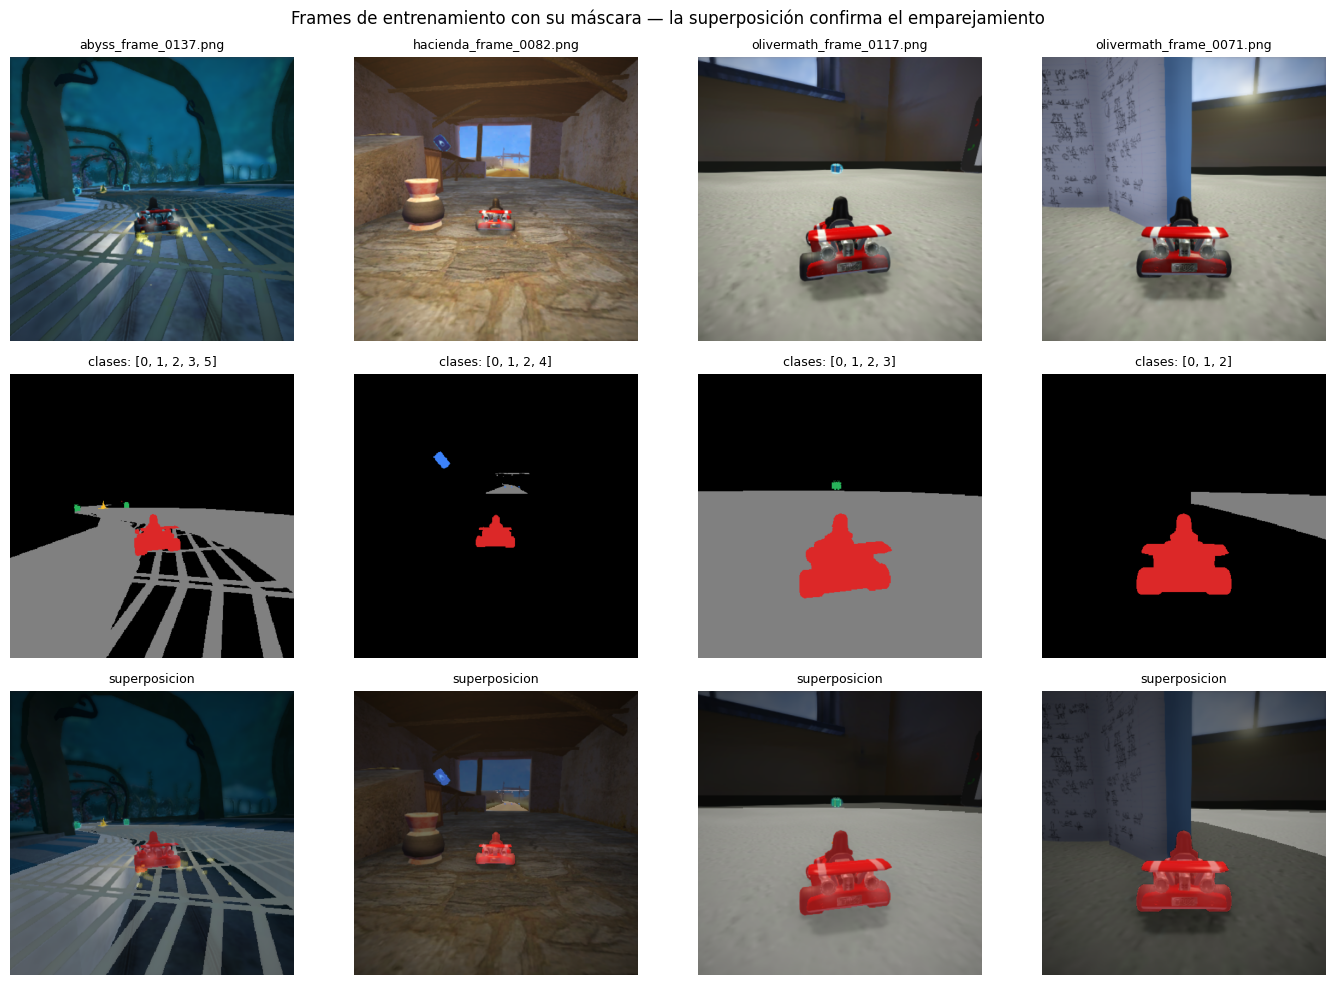

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for col, i in enumerate(random.Random(1).sample(range(len(train_ds)), 4)):
    im, mk = train_ds[i]
    axes[0, col].imshow(im.permute(1, 2, 0).numpy())
    axes[0, col].set_title(os.path.basename(train_ds.samples[i][0]), fontsize=9)
    axes[1, col].imshow(label_to_color(mk.numpy()))
    axes[1, col].set_title('clases: %s' % mk.unique().tolist(), fontsize=9)
    axes[2, col].imshow(overlay(im.numpy(), mk.numpy()))
    axes[2, col].set_title('superposicion', fontsize=9)
    for r in range(3): axes[r, col].axis('off')
fig.suptitle('Frames de entrenamiento con su máscara — la superposición confirma el emparejamiento', fontsize=12)
fig.tight_layout(); plt.show()

### Desbalance de clases

Es extremo, y define todo el diseño.

In [4]:
d = json.load(open('class_weights.json'))
counts = np.array(d['pixel_counts'])
pct = 100 * counts / counts.sum()
frames = np.zeros(NUM_CLASSES, dtype=int)
for i in range(len(train_ds)):
    frames[np.unique(train_ds[i][1].numpy())] += 1

w = weights_from_counts(counts, power=0.30)
print('%-12s %14s %10s %9s %8s' % ('clase', 'pixeles', '% pixeles', 'frames', 'peso'))
print('-' * 58)
for i, n in enumerate(CLASS_NAMES):
    print('%-12s %14d %10.5f %9d %8.4f' % (n, counts[i], pct[i], frames[i], w[i]))

clase               pixeles  % pixeles    frames     peso
----------------------------------------------------------
background         35104083   53.56458      1000   0.1571
track              28717785   43.81986      1000   0.1669
kart                1597638    2.43780      1000   0.3970
pickup                80568    0.12294       433   0.9726
nitro                 16789    0.02562       394   1.5570
bomb                  12332    0.01882       168   1.7080
projectile             6805    0.01038         1   2.0415


Tres consecuencias que condicionan el resto del proyecto:

1. Un modelo que prediga «todo es background o track» acierta el **97%** de los píxeles y es
   inútil. Por eso la métrica es **IoU por clase**, nunca *accuracy*.
2. Hace falta ponderar la `CrossEntropyLoss`. Se usa `peso = (1/frecuencia)^0.30`, normalizado
   a media 1. El inverso puro daría a `projectile` un peso de miles y desestabilizaría el
   entrenamiento.
3. **`projectile` aparece en 1 solo frame de los 1000 de entrenamiento** y `bomb` en 168. Su
   IoU bajo será falta de datos, no del modelo.

## 3. El modelo

El encoder de SAM 2 devuelve `backbone_fpn`: **3 niveles de 256 canales** a strides 4, 8 y 16.
La cabeza los fusiona de grueso a fino al estilo FPN y termina en una convolución 1×1 a 7 clases.

- **Entrada** cruda en `[0,1]`. La normalización de SAM 2 se aplica *dentro* del `forward`,
  como buffers, para que viaje con los pesos.
- **Salida** logits crudos, sin softmax: `CrossEntropyLoss` los espera así.
- **Descongelado configurable**: `unfreeze_blocks=N` libera los N últimos bloques de Hiera y
  `unfreeze_neck` el cuello FPN. El modelo final libera los 48 bloques y el cuello; solo
  quedan fijos los embeddings de posición y de parches.
- **Dos learning rates**: la cabeza, nueva, aprende con 1e-3 y el encoder con 1e-5. Si el
  encoder queda congelado por completo, corre bajo `torch.no_grad()` y no se construye su grafo.

La celda construye la arquitectura final sin descargar pesos, solo para contar parámetros.

In [5]:
from models import SAM2Segmenter, save_model, load_model

modelo = SAM2Segmenter(backbone='large', image_size=448, dim=256, freeze_encoder=True,
                       unfreeze_blocks=48, unfreeze_neck=True, pretrained=False)

M = lambda ps: sum(p.numel() for p in ps) / 1e6
enc, bloques = modelo.encoder, modelo.encoder.trunk.blocks
total = M(enc.parameters())
print('cabeza nueva     : %7.2f M' % M(modelo.head.parameters()))
print('encoder de SAM 2 : %7.2f M  (%d bloques Hiera + cuello FPN)' % (total, len(bloques)))
print('encoder afinado  : %7.2f M' % M(modelo.encoder_trainable_parameters()))
print('encoder fijo     : %7.4f M  (embeddings de posicion y de parches)'
      % M(p for p in enc.parameters() if not p.requires_grad))

print()
print('%-12s %11s %9s' % ('descongelado', 'parametros', 'encoder'))
print('-' * 34)
for nombre, n in [('cuello FPN', 0), ('3 bloques', 3), ('15 bloques', 15),
                  ('28 bloques', 28), ('48 bloques', 48)]:
    v = M(enc.neck.parameters()) + M(p for b in bloques[len(bloques) - n:] for p in b.parameters())
    print('%-12s %9.2f M %8.1f%%' % (nombre, v, 100 * v / total))

fuera = [n for n, p in modelo.named_parameters() if p.requires_grad
         and not n.startswith(('head.', 'encoder.trunk.blocks.', 'encoder.neck.'))]
assert not fuera, fuera[:3]
print('\nVerificado: solo se entrenan la cabeza, los bloques de Hiera y el cuello.')

cabeza nueva     :    2.56 M
encoder de SAM 2 :  212.70 M  (48 bloques Hiera + cuello FPN)
encoder afinado  :  212.67 M
encoder fijo     :  0.0376 M  (embeddings de posicion y de parches)

descongelado  parametros   encoder
----------------------------------
cuello FPN        0.55 M      0.3%
3 bloques        48.37 M     22.7%
15 bloques      106.86 M     50.2%
28 bloques      158.72 M     74.6%
48 bloques      212.67 M    100.0%

Verificado: solo se entrenan la cabeza, los bloques de Hiera y el cuello.


## 4. Entrenamiento

El loop vive en `train.py` para poder lanzarlo también como script en el servidor, donde un
kernel de Jupyter por SSH sería frágil. Aquí se importa y se ejecuta.

**El modelo final se entrenó en una GPU NVIDIA H200** con este comando:

```bash
python train.py --data-root data --backbone large --size 448 --dim 256 \
    --lr 1e-3 --weight-power 0.30 --unfreeze-blocks 48 --unfreeze-neck \
    --encoder-lr 1e-5 --epochs 30 --early-stop 8 --batch-size 8
```

La celda siguiente ejecuta **el mismo loop con la misma configuración** sobre un subconjunto,
para que se vea funcionando y se identifiquen las métricas por época. Los resultados
definitivos se calculan en la sección 5 sobre `model.th`, que es el modelo entrenado completo.

Cada época imprime la **tabla de IoU por clase**, que es la métrica que guía todas las decisiones.

In [6]:
from train import train
import argparse

args = argparse.Namespace(
    data_root=DATA_ROOT, backbone='large', size=448, dim=256,
    epochs=4, lr=1e-3, weight_decay=1e-4, batch_size=4, num_workers=0,
    limit=64, out='salidas/demo.th', ckpt_dir='salidas/demo_ck', resume=None,
    weights='class_weights.json', no_weights=False, weight_power=0.30, weight_clip=10.0,
    no_augment=False, unfreeze_blocks=48, unfreeze_neck=True, encoder_lr=1e-5,
    device='auto', runs_csv='salidas/demo_runs.csv', notes='demo', early_stop=0)

demo = train(args)

device       : cpu
torch        : 2.14.0
data-root    : data
tracks train : ['abyss', 'gran_paradiso_island', 'hacienda', 'olivermath']
tracks val   : ['lighthouse', 'volcano_island']
backbone     : large | dim 256 | size 448
out          : salidas/demo.th
batches      : train=16 val=16
class_weights de class_weights.json (power=0.30, clip=10.0)
class_weights: [0.1571, 0.1669, 0.397, 0.9726, 1.557, 1.708, 2.0415]


parametros   : 215.23 M entrenables / 0.04 M congelados
descongelado : 48 bloques finales + cuello FPN -> 212.67 M con lr 1.0e-05



=== EPOCH 0 | VAL ===
background   0.8120
track        0.8226
kart         0.3342
pickup       0.0000
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.3938   (5 clases presentes)
acc_global   0.8771
loss_train   0.6919
loss_val     0.6349
lr           1.0e-03
seg          98.2


nuevo mejor mIoU 0.3938 -> salidas/demo.th



=== EPOCH 1 | VAL ===
background   0.7937
track        0.7568
kart         0.4686
pickup       0.0000
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.4038   (5 clases presentes)
acc_global   0.8630
loss_train   0.2414
loss_val     0.3950
lr           1.0e-03
seg          79.3


...


=== EPOCH 2 | VAL ===
background   0.7955
track        0.7626
kart         0.6428
pickup       0.1131
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.4628   (5 clases presentes)
acc_global   0.8717
loss_train   0.1804
loss_val     0.4468
lr           1.0e-03
seg          71.9


nuevo mejor mIoU 0.4628 -> salidas/demo.th



=== EPOCH 3 | VAL ===
background   0.7911
track        0.7503
kart         0.6809
pickup       0.1960
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.4837   (5 clases presentes)
acc_global   0.8687
loss_train   0.1530
loss_val     0.5077
lr           1.0e-03
seg          73.3


nuevo mejor mIoU 0.4837 -> salidas/demo.th



--- a donde van los pixeles de cada clase real ---
background      5973606 px  ->  background 97.8%,  track 2.0%,  kart 0.2%
track           6498869 px  ->  track 76.5%,  background 21.5%,  kart 2.0%
kart             354685 px  ->  kart 96.1%,  track 2.1%,  background 1.7%
pickup            11721 px  ->  background 71.7%,  pickup 22.9%,  kart 5.3%
nitro        (no aparece en validacion)
bomb               6175 px  ->  kart 60.1%,  track 27.4%,  background 12.5%
projectile   (no aparece en validacion)

FIN. pico 0.4837 en la epoca 3 | top5 0.4360 | sigma 0.0381  (modelo en salidas/demo.th)


## 5. Métricas

El mIoU se calcula acumulando **una sola matriz de confusión sobre todo el conjunto de
validación**, nunca promediando el IoU de cada lote: si una clase no aparece en un lote su IoU
sale 0/0 y contamina el promedio.

In [7]:
modelo = load_model('model.th', device=device)
print('modelo final: backbone %s, dim %d, entrada %d, %d bloques + cuello afinados'
      % (modelo.backbone, modelo.dim, modelo.image_size, modelo.unfreeze_blocks))
print('cabeza %.2f M | encoder afinado %.2f M de %.2f M'
      % (M(modelo.head.parameters()), M(modelo.encoder_trainable_parameters()),
         M(modelo.encoder.parameters())))

val_loader = load_data(DATA_ROOT, 'val', size=(448, 448), batch_size=4, num_workers=0)
cm = ConfusionMatrix()
with torch.no_grad():
    for im, mk in val_loader:
        cm.add(modelo(im.to(device)).argmax(1), mk.to(device))

print()
print(format_iou_table(cm.class_iou, cm.miou,
                       extra={'acc_global': '%.4f' % cm.global_accuracy},
                       title='RESULTADO FINAL | VALIDACION'))

modelo final: backbone large, dim 256, entrada 448, 48 bloques + cuello afinados
cabeza 2.56 M | encoder afinado 212.67 M de 212.70 M



=== RESULTADO FINAL | VALIDACION ===
background   0.8791
track        0.8743
kart         0.8158
pickup       0.5496
nitro        0.4562
bomb         0.2180
projectile   0.4124
-------------------------
mIoU         0.6008   (7 clases presentes)
acc_global   0.9327


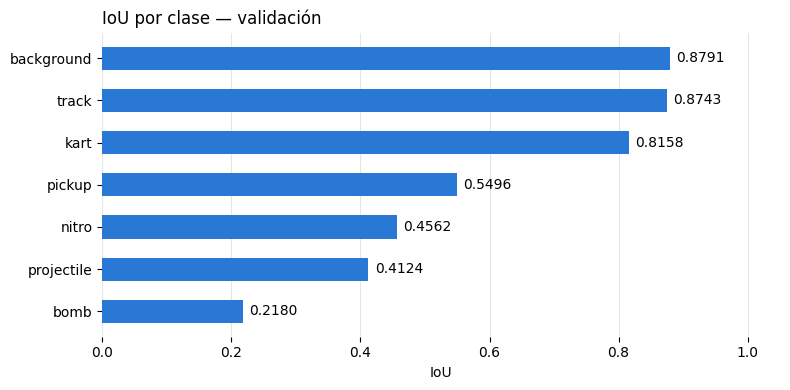

In [8]:
iou = [float(v) for v in cm.class_iou]
orden = np.argsort([v if v == v else -1 for v in iou])
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([CLASS_NAMES[i] for i in orden], [0 if iou[i] != iou[i] else iou[i] for i in orden],
        color='#2a78d6', height=0.55)
for y, i in enumerate(orden):
    v = iou[i]
    ax.text((0 if v != v else v) + 0.01, y, 'nan' if v != v else '%.4f' % v,
            va='center', fontsize=10)
ax.set_xlim(0, 1.05); ax.set_xlabel('IoU'); ax.set_title('IoU por clase — validación', loc='left')
for s in ax.spines.values(): s.set_visible(False)
ax.xaxis.grid(True, color='#e6e5e1'); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

### A dónde van los píxeles que falla

El IoU dice *qué* clase falla; esto dice *contra quién*, que es lo que decide el siguiente
experimento. Si los píxeles de `bomb` acaban en `background` es sub-detección; si acaban en
`nitro` es confusión entre objetos parecidos, y la solución es distinta.

In [9]:
print(format_confusion(cm))

--- a donde van los pixeles de cada clase real ---
background     46586947 px  ->  background 98.1%,  track 1.8%,  kart 0.0%
track          51786135 px  ->  track 89.0%,  background 10.4%,  kart 0.4%
kart            1754363 px  ->  kart 92.7%,  track 5.8%,  bomb 0.7%
pickup           112247 px  ->  pickup 97.6%,  background 1.6%,  track 0.4%
nitro              7645 px  ->  nitro 82.9%,  background 5.7%,  kart 5.2%
bomb              87841 px  ->  pickup 48.7%,  bomb 33.8%,  kart 7.5%
projectile        16822 px  ->  projectile 41.6%,  track 35.9%,  kart 19.2%


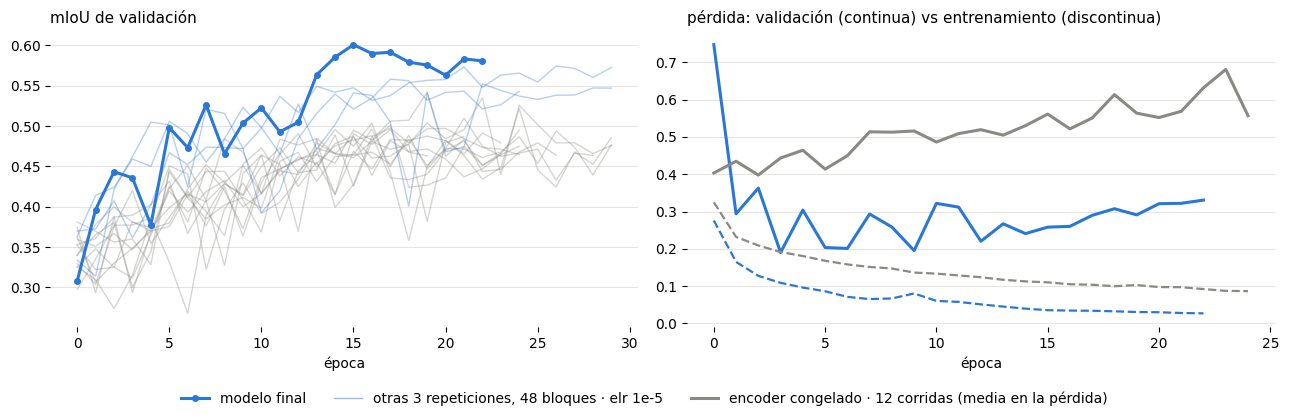

modelo final: pico de mIoU 0.6007 en la epoca 15 de 23
perdida de validacion: minima 0.1901 en la epoca 3, 0.2581 en la epoca del pico
en la epoca del pico la validacion es 7.3 veces la de entrenamiento (0.0355)


In [10]:
import csv
from matplotlib.lines import Line2D

LOTE = '20260909_204201'
FINAL = 'large_s448_d256_lr0.001_p0.30_b48_el1e-05_r4'
AZUL, GRIS = '#2a78d6', '#8a8984'
curvas = {}
for r in csv.DictReader(open('experimentos/resultados/epocas.csv')):
    if r['lote'] == LOTE and ('_none_' in r['notes'] or '_b48_el1e-05_' in r['notes']):
        curvas.setdefault(r['notes'], []).append((int(r['epoch']), float(r['val_miou']),
                                                  float(r['train_loss']), float(r['val_loss'])))
curvas = {t: sorted(v) for t, v in curvas.items()}

def media_por_epoca(corridas, i):
    out = []
    for e in range(max(len(c) for c in corridas)):
        vivas = [c[e][i] for c in corridas if len(c) > e]
        if len(vivas) < len(corridas) // 2: break
        out.append(sum(vivas) / len(vivas))
    return out

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for tag, filas in sorted(curvas.items(), key=lambda kv: kv[0] == FINAL):
    ep, mio = [f[0] for f in filas], [f[1] for f in filas]
    if tag == FINAL:
        a1.plot(ep, mio, color=AZUL, lw=2.2, marker='o', ms=4, zorder=3)
    else:
        a1.plot(ep, mio, color=AZUL if '_b48_' in tag else GRIS, lw=1, alpha=0.35)

ep, mio, trl, val = map(list, zip(*curvas[FINAL]))
congeladas = [v for t, v in curvas.items() if '_none_' in t]
a2.plot(ep, val, color=AZUL, lw=2.2)
a2.plot(ep, trl, color=AZUL, lw=1.6, ls='--')
a2.plot(media_por_epoca(congeladas, 3), color=GRIS, lw=2.2)
a2.plot(media_por_epoca(congeladas, 2), color=GRIS, lw=1.6, ls='--')

a1.set_title('mIoU de validación', loc='left', fontsize=11)
a2.set_title('pérdida: validación (continua) vs entrenamiento (discontinua)', loc='left', fontsize=11)
for a in (a1, a2):
    a.set_xlabel('época'); a.yaxis.grid(True, color='#e6e5e1'); a.set_axisbelow(True)
    for s in a.spines.values(): s.set_visible(False)
fig.legend([Line2D([], [], color=AZUL, lw=2.2, marker='o', ms=4),
            Line2D([], [], color=AZUL, lw=1, alpha=0.5),
            Line2D([], [], color=GRIS, lw=2.2)],
           ['modelo final', 'otras 3 repeticiones, 48 bloques · elr 1e-5',
            'encoder congelado · 12 corridas (media en la pérdida)'],
           loc='lower center', ncol=3, frameon=False, fontsize=10)
fig.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

e = mio.index(max(mio))
print('modelo final: pico de mIoU %.4f en la epoca %d de %d' % (max(mio), ep[e], len(ep)))
print('perdida de validacion: minima %.4f en la epoca %d, %.4f en la epoca del pico'
      % (min(val), ep[val.index(min(val))], val[e]))
print('en la epoca del pico la validacion es %.1f veces la de entrenamiento (%.4f)' % (val[e] / trl[e], trl[e]))

### Las 113 corridas

Se registraron 113 corridas en cinco tandas. Las tablas resumen **efectos medios**, más fiables que el ranking individual:
con σ ≈ 0.020 de ruido entre épocas, dos corridas que difieran menos de ~0.04 son
indistinguibles.

Cada eje se promedia **solo dentro de la tanda donde está cruzado**. Mezclar tandas desbalanceadas
invierte conclusiones: las corridas a 1024 solo se hicieron con las configuraciones buenas.

In [11]:
from statistics import mean, stdev

def num(v):
    try: return float(v)
    except ValueError: return float('nan')

def medias(filas, eje):
    g = {}
    for r in filas:
        v = num(r['best_miou'])
        if v == v and r.get(eje): g.setdefault(r[eje], []).append(v)
    o = sorted(g.items(), key=lambda kv: -mean(kv[1]))
    return '   '.join('%s=%.4f (n=%d)' % (k, mean(v), len(v)) for k, v in o)

todas = list(csv.DictReader(open('experimentos/resultados/configuraciones.csv')))
tanda = lambda lote: [r for r in todas if r['lote'] == lote]
print('%d corridas registradas' % len(todas))

t1, t2, t4 = tanda('20260909_165356'), tanda('20260909_183741'), tanda('20260909_204201')

print()
print('TANDA 1 · %d corridas · backbone x dim x lr x power, encoder congelado · pico medio' % len(t1))
for eje in ['backbone', 'dim', 'lr', 'weight_power']:
    print('  %-14s %s' % (eje, medias(t1, eje)))

print()
print('TANDA 2 · %d corridas · backbone x size x dim · pico medio' % len(t2))
for eje in ['size', 'dim', 'backbone']:
    print('  %-14s %s' % (eje, medias(t2, eje)))

print()
print('TANDA 4 · %d corridas · descongelado x encoder-lr x 4 repeticiones · top5 medio' % len(t4))
ELRS = [('0.0001', '1e-4'), ('1e-05', '1e-5'), ('1e-06', '1e-6')]
print('  %-12s' % '' + ''.join('%17s' % ('elr ' + e) for _, e in ELRS))
for m, nombre in [('none', 'ninguno'), ('neck', 'cuello FPN'), ('b3', '3 bloques'),
                  ('b15', '15 bloques'), ('b28', '28 bloques'), ('b48', '48 bloques')]:
    celdas = []
    for e, _ in ELRS:
        v = [num(r['top5']) for r in t4 if r['modo'] == m and r['encoder_lr'] == e]
        celdas.append('%.4f (n=%d)' % (mean(v), len(v)))
    print('  %-12s' % nombre + ''.join('%17s' % c for c in celdas))

control = [num(r['top5']) for r in t4 if r['modo'] == 'none']
elegida = [num(r['top5']) for r in t4 if r['modo'] == 'b48' and r['encoder_lr'] == '1e-05']
print()
for nombre, v in [('congelado, 12 replicas', control), ('48 bloques · elr 1e-5', elegida)]:
    print('  %-24s top5 %.4f ± %.4f   rango [%.4f, %.4f]' % (nombre, mean(v), stdev(v), min(v), max(v)))

113 corridas registradas

TANDA 1 · 24 corridas · backbone x dim x lr x power, encoder congelado · pico medio
  backbone       large=0.5118 (n=8)   base_plus=0.5005 (n=8)   small=0.4921 (n=8)
  dim            256=0.5116 (n=12)   128=0.4914 (n=12)
  lr             0.0003=0.5020 (n=12)   0.001=0.5009 (n=12)
  weight_power   0.3=0.5016 (n=12)   0.2=0.5013 (n=12)

TANDA 2 · 7 corridas · backbone x size x dim · pico medio
  size           1024=0.5146 (n=3)   448=0.5137 (n=4)
  dim            256=0.5211 (n=3)   512=0.5089 (n=4)
  backbone       large=0.5248 (n=3)   base_plus=0.5061 (n=4)

TANDA 4 · 72 corridas · descongelado x encoder-lr x 4 repeticiones · top5 medio
                       elr 1e-4         elr 1e-5         elr 1e-6
  ninguno          0.4834 (n=4)     0.4940 (n=4)     0.4961 (n=4)
  cuello FPN       0.4636 (n=4)     0.4867 (n=4)     0.4847 (n=4)
  3 bloques        0.4699 (n=4)     0.4828 (n=4)     0.4700 (n=4)
  15 bloques       0.4998 (n=4)     0.5094 (n=4)     0.5050 (n=4)


### Validación cruzada por circuito

La tanda 4 eligió la configuración mirando `lighthouse` y `volcano_island`, así que su mejora
puede estar inflada por esa elección. La tanda 5 repite la comparación congelado vs afinado con
los otros circuitos en validación: cada circuito queda en validación exactamente una vez.

In [12]:
from utils import PLIEGUES

cv = [r for r in todas if r['backbone'] == 'large'
      and r['lote'] in ('20260909_204201', '20260910_095607')]

print('%-8s %-34s %24s %24s %8s' % ('pliegue', 'validacion', 'congelado · top5', 'afinado · top5', 'delta'))
print('-' * 102)
deltas = []
for p in sorted(PLIEGUES):
    base = [num(r['top5']) for r in cv if r['pliegue'] == p and r['modo'] == 'none']
    afin = [num(r['top5']) for r in cv if r['pliegue'] == p and r['modo'] == 'b48'
            and r['encoder_lr'] == '1e-05']
    deltas.append(mean(afin) - mean(base))
    print('%-8s %-34s %.4f ± %.4f (n=%2d) %.4f ± %.4f (n=%2d) %+8.4f'
          % (p, ', '.join(PLIEGUES[p]), mean(base), stdev(base), len(base),
             mean(afin), stdev(afin), len(afin), deltas[-1]))
print('-' * 102)
print('mejora media %+.4f · minima %+.4f · maxima %+.4f · positiva en %d de %d pliegues'
      % (mean(deltas), min(deltas), max(deltas), sum(d > 0 for d in deltas), len(deltas)))

pliegue  validacion                                 congelado · top5           afinado · top5    delta
------------------------------------------------------------------------------------------------------
f1       volcano_island, lighthouse         0.4912 ± 0.0107 (n=12) 0.5641 ± 0.0207 (n= 4)  +0.0729
f2       gran_paradiso_island, hacienda     0.5835 ± 0.0102 (n= 2) 0.5960 ± 0.0172 (n= 2)  +0.0125
f3       abyss, olivermath                  0.4618 ± 0.0361 (n= 2) 0.4871 ± 0.0318 (n= 2)  +0.0253
------------------------------------------------------------------------------------------------------
mejora media +0.0369 · minima +0.0125 · maxima +0.0729 · positiva en 3 de 3 pliegues


## 6. Imágenes segmentadas

La demostración de que el modelo hace su trabajo. Los circuitos que se muestran **no se usaron
durante el entrenamiento**.

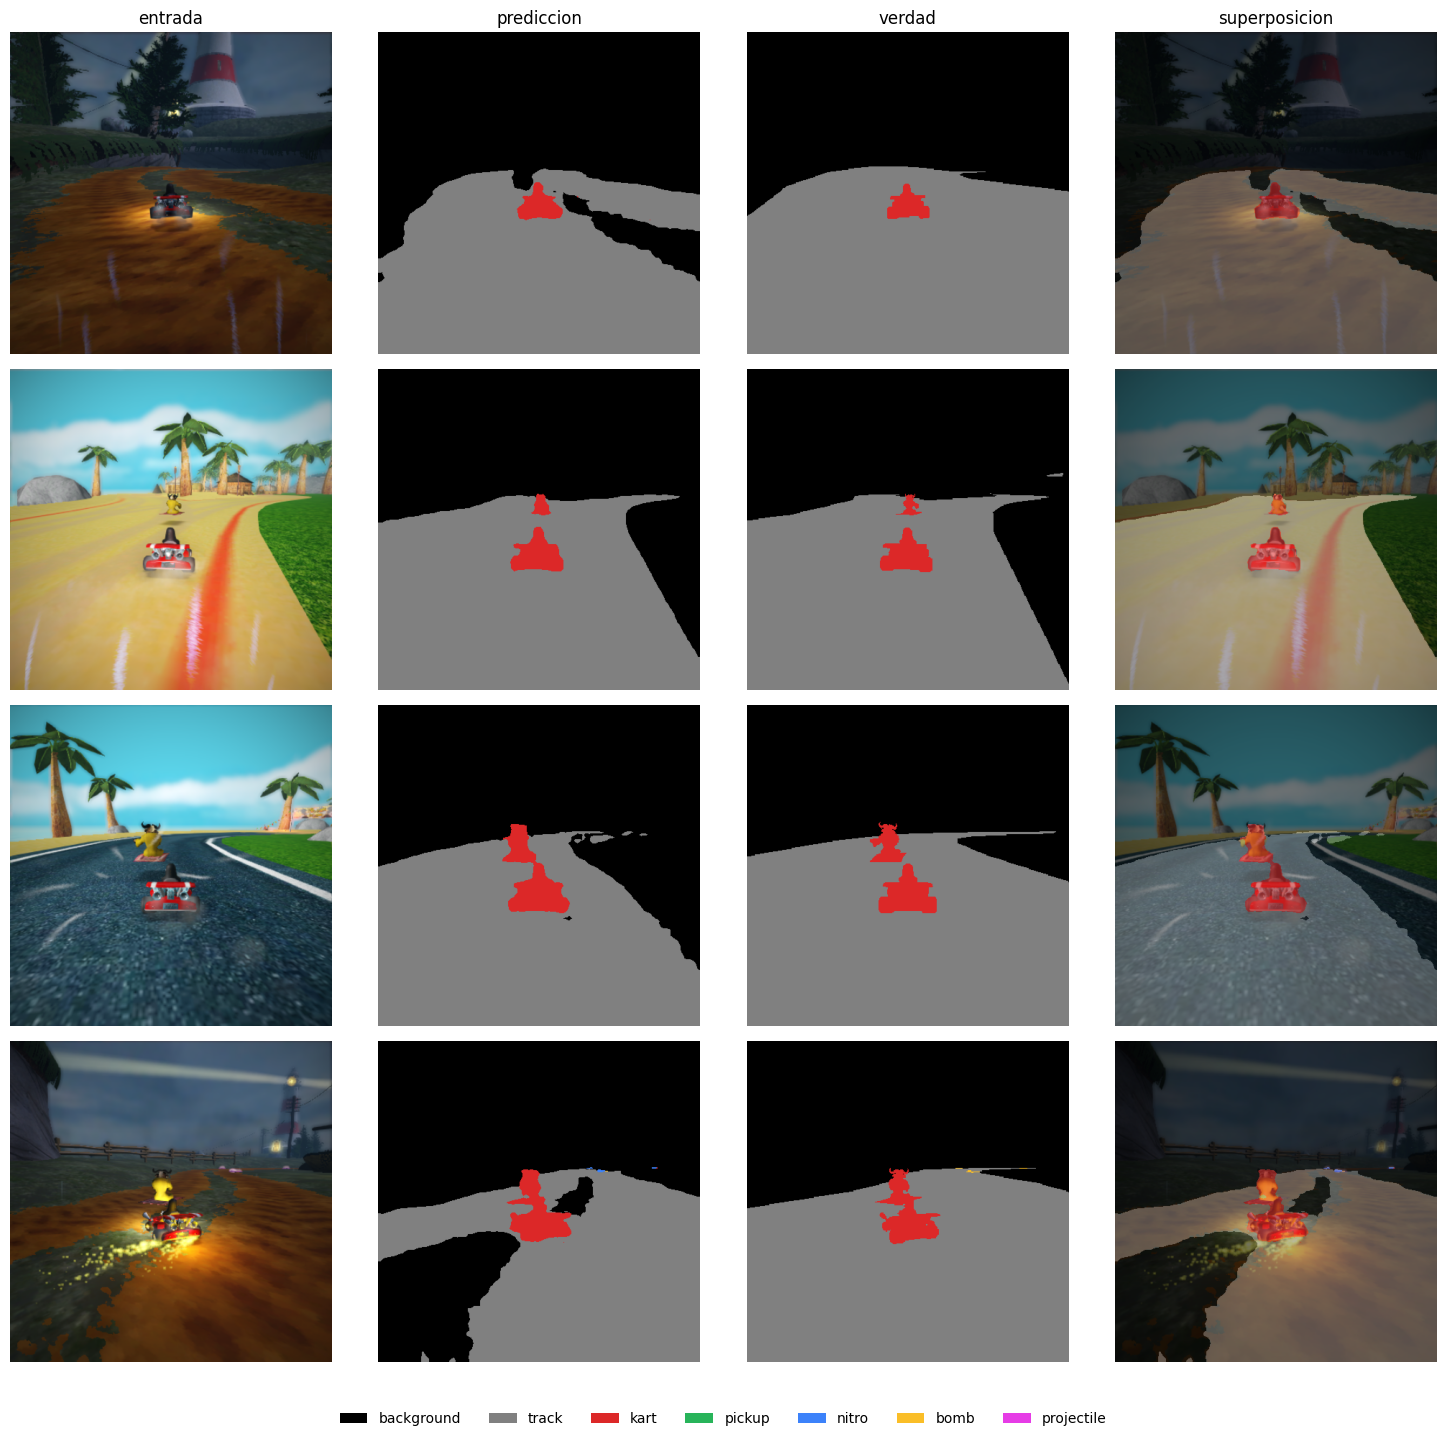

In [13]:
def segmentar(ds, idx):
    im, gt = ds[idx]
    with torch.no_grad():
        pred = modelo(im[None].to(device)).argmax(1)[0].cpu().numpy()
    return im, gt.numpy(), pred

elegidos = random.Random(3).sample(range(len(val_ds)), 4)
fig, axes = plt.subplots(len(elegidos), 4, figsize=(15, 3.6*len(elegidos)))
for r, idx in enumerate(elegidos):
    im, gt, pred = segmentar(val_ds, idx)
    inter = np.logical_and(pred == gt, gt > 0).sum()
    union = np.logical_or(pred > 0, gt > 0).sum()
    for c, (dat, tit) in enumerate([(im.permute(1,2,0).numpy(), 'entrada'),
                                    (label_to_color(pred), 'prediccion'),
                                    (label_to_color(gt), 'verdad'),
                                    (overlay(im.numpy(), pred), 'superposicion')]):
        axes[r, c].imshow(dat); axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(tit, fontsize=12)
    axes[r, 0].set_ylabel(os.path.basename(val_ds.samples[idx][0]), fontsize=8)
handles = [plt.Rectangle((0,0),1,1, fc=PALETTE[i]/255.) for i in range(NUM_CLASSES)]
fig.legend(handles, CLASS_NAMES, loc='lower center', ncol=7, frameon=False, fontsize=10)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 7. Conclusiones

### Resultado

**mIoU 0.6008** sobre 500 frames de dos circuitos que el modelo nunca vio, con el encoder de
SAM 2 Hiera-Large afinado entero a un learning rate cien veces menor que el de la cabeza.

### Referencia: U-Net desde cero

Una U-Net entrenada desde cero con el mismo dataset y el mismo split por circuito:

| clase | U-Net desde cero | SAM 2 | |
|---|---|---|---|
| background | 0.7768 | **0.8791** | +0.102 |
| track | 0.7365 | **0.8743** | +0.138 |
| kart | 0.6709 | **0.8158** | +0.145 |
| pickup | 0.5013 | **0.5496** | +0.048 |
| bomb | 0.0194 | **0.2180** | +0.199 |
| projectile | 0.0000 | **0.4124** | +0.412 |
| nitro | **0.5352** | 0.4562 | −0.079 |
| **mIoU** | 0.4629 | **0.6008** | **+0.138** |

SAM 2 gana en 6 de las 7 clases, un 30% relativo de mejora en mIoU; `track` pasa de 0.7365 a
0.8743.

### Qué mueve la aguja y qué no

Con el encoder congelado, los únicos ejes con efecto real son los de **capacidad**:

| eje | efecto |
|---|---|
| backbone `small` → `large` | **+0.020** |
| `dim` 128 → 256 | **+0.020** |
| `dim` 256 → 512 | −0.012, se agota |
| resolución 448 → 1024 | +0.001 por 5–7× el coste |
| learning rate 1e-3 ↔ 3e-4 | 0.001, nada |
| exponente de pesos 0.20 ↔ 0.30 | 0.000, nada |

### Descongelar el encoder: solo entero y despacio

La tanda 4 cruzó cuánto encoder se descongela con su learning rate, repitiendo cada punto
cuatro veces:

- Descongelar solo el cuello o los últimos bloques **empeora** en las tres velocidades.
- Descongelar **los 48 bloques con `elr` 1e-5** da un `top5` de 0.564 frente a 0.491 ± 0.011
  de 12 réplicas del congelado. Las cuatro repeticiones quedan por encima de las doce.
- Con `elr` 1e-6 los pesos apenas se mueven y todo converge al congelado.

### Validación cruzada

Afinar el encoder mejora en los tres pliegues (+0.073, +0.012, +0.025). La configuración se
eligió con f1, por eso su mejora es la más alta; la media, **+0.037**, es la estimación realista. Con tres pliegues la dirección es consistente pero no estadísticamente concluyente,
y en f2 el modelo afinado acaba con más pérdida de validación que el congelado (0.534 frente a
0.490) aunque su mIoU sea mayor. Afinar 213 M de parámetros con 1000 imágenes está al límite.

### ¿Hay sobreajuste?

Depende de qué se mire:

- **Por pérdida, sí.** La de entrenamiento baja en todas las épocas, pero la de validación toca su
  mínimo entre las épocas 1 y 5 y después se estanca o sube, con el encoder congelado y con el
  afinado. Afinar abre más la brecha: en la época elegida, la de validación es 8–22 veces la de
  entrenamiento, frente a 5–10 veces con el encoder congelado. Aun así, el afinado acaba con menos
  pérdida de validación que el congelado en f1 y f3 (0.28 frente a 0.51, 0.67 frente a 0.75) y con
  algo más en f2 (0.53 frente a 0.49).
- **Por mIoU, no.** El mIoU de validación sigue subiendo mientras la pérdida sube, hasta la época
  16–27 de media. El modelo se vuelve demasiado seguro en los píxeles que falla, que es lo que la
  CrossEntropy castiga, pero acierta más píxeles. Por eso se elige por mIoU y no por pérdida.
- **La validación son circuitos enteros que no se usaron para entrenar**, y la mejora se repite
  en los tres pliegues de la validación cruzada.

### Sobre la fiabilidad de estas cifras

- La σ del mIoU entre épocas consecutivas es **≈ 0.020**, y entre corridas idénticas **0.011**.
  Por eso las decisiones se tomaron con medias sobre varias corridas y no con el ranking individual.
- **El 0.6008 está optimistamente sesgado**: es la mejor de 4 repeticiones, medida en el mismo
  conjunto con el que se eligió. La media de las cuatro es 0.571 de pico y 0.564 de `top5`.

### Límite del dataset, no del modelo

`projectile` aparece en **1 frame de los 1000** de entrenamiento y en 1 de los 500 de
validación: su IoU de 0.41 se mide sobre ese único frame y es ruido, no una capacidad
demostrada. `bomb` aparece en 168 frames y es la clase más baja, con 0.218, pero no por
sub-detección: la matriz de confusión muestra que el 48.7% de sus píxeles acaba en `pickup`.
El modelo encuentra el objeto y duda entre dos clases de aspecto parecido.